## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import pickle
import cv2

import skimage as ski
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
from scipy.spatial import KDTree
from skimage.measure import label, regionprops

from neural_reconstruction.core.preprocessing import dilate_epidermis_vertically
from neural_reconstruction.core.preprocessing import SkinAnalysisPipeline
from neural_reconstruction.core.topology import TopologyBuilder
from neural_reconstruction.core.pathfinding import PathFinder
from neural_reconstruction.core.evaluation import (
    GraphPointExtractor,
    extract_graph_points,
    compute_average_hausdorff_distance,
    compute_point_min_distances,
)

## 2. Config

In [2]:
BASE_PATH = Path('/home/pony/projects/ienf_q/')
DATASET_DIR = BASE_PATH / 'data/datasets'
DATA_DIR    = BASE_PATH / 'nas/jia/data_0320'

# Auto-discover all sample IDs that have both CSV and pkl
SAMPLE_IDS = sorted(
    p.stem.removeprefix('dataset_')
    for p in DATASET_DIR.glob('dataset_*.csv')
    if not p.stem.endswith('_paths')
    and (DATASET_DIR / f"{p.stem}_paths.pkl").exists()
)


# Seed graph
SEGMENT_LENGTH = 3

# A* search
SEARCH_RADIUS        = 100
BBOX_PADDING         = 10


PATH_FINDING_BBOX_PADDING = 10
HAUSDORFF_INF_SENTINEL = 10**10
HAUSDORFF_IN_LABEL_TOLERANCE = 10

BRIGHT_THRESHOLD = 128  # for frac_bright feature

print(f"Found {len(SAMPLE_IDS)} sample(s): {SAMPLE_IDS}")

Found 17 sample(s): ['S1140-2_a', 'S1140-2_b', 'S1585-2_a', 'S1585-2_b', 'S1616-2_a', 'S222-2_a', 'S222-2_b', 'S226-2_a', 'S226-2_b', 'S236-2_a', 'S236-2_b', 'S341-2_a', 'S341-2_b', 'S487-2_a', 'S487-2_b', 'S558-2_a', 'S558-2_b']


## 3. 特徵萃取

In [3]:
def extract_path_features(path, orig_img, threshold=128):
    """Extract image-based features along an A* path."""
    pts = np.array(path)
    intensities = orig_img[pts[:, 0], pts[:, 1]].astype(np.float32)

    # Max perpendicular deviation from the straight line connecting endpoints
    start, end = pts[0].astype(float), pts[-1].astype(float)
    line_vec = end - start
    line_len = np.linalg.norm(line_vec)
    if line_len > 0:
        max_deviation = float(np.max(np.abs(np.cross(line_vec / line_len, pts - start))))
    else:
        max_deviation = 0.0

    return {
        # Intensity statistics
        'mean_intensity':     float(np.mean(intensities)),
        'max_intensity':      float(np.max(intensities)),
        'min_intensity':      float(np.min(intensities)),
        'median_intensity':   float(np.median(intensities)),
        'std_intensity':      float(np.std(intensities)),
        'intensity_q25':      float(np.percentile(intensities, 25)),
        'intensity_q75':      float(np.percentile(intensities, 75)),
        'frac_bright':        float(np.mean(intensities > threshold)),
        # Endpoint intensity (are seeds on bright tissue?)
        'endpoint_intensity': float((intensities[0] + intensities[-1]) / 2),
        # Path shape
        'max_deviation':      max_deviation,
    }

def compute_path_hausdorff_sum(path: list, gt_kdtree: KDTree) -> float:
    """Sum of min distances from each path point to the nearest GT pixel."""
    path_pts = np.array(path)
    dists, _ = gt_kdtree.query(path_pts)
    return float(np.sum(dists))


def load_and_featurize(sample_id, dataset_dir, data_dir, threshold=128):
    """Load CSV + pkl + image, return feature DataFrame."""
    base_path  = data_dir / sample_id
    image      = cv2.imread(base_path / "image.png",    cv2.IMREAD_COLOR_RGB)[:, :, 1]  # 只取綠色通道
    mask       = cv2.imread(base_path / "mask.png" ,    cv2.IMREAD_GRAYSCALE)
    annotation = cv2.imread(base_path / "weka.png" ,    cv2.IMREAD_GRAYSCALE)
    label_img  = cv2.imread(base_path / "label.png",    cv2.IMREAD_GRAYSCALE)

    h, w = annotation.shape

    roi_mask = dilate_epidermis_vertically(mask, offset_px=50)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (51, 51))
    background = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
    image = cv2.subtract(image, background)

    roi_image = cv2.bitwise_and(image, image, mask=roi_mask)
    roi_annotation = cv2.bitwise_and(annotation, annotation, mask=roi_mask)

    # apply opening to roi_annotation to remove small noise
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_OPEN, kernel)

    # apply closing to roi_annotation to fill small holes
    roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_CLOSE, kernel)
        
    topology_builder = TopologyBuilder(segment_length=SEGMENT_LENGTH)
    seed_graph = topology_builder.build_seed_graph(roi_annotation, roi_image)
    labeled = np.asarray(label(roi_annotation, connectivity=2))

    for node in seed_graph.nodes():
        y, x = node
        seed_graph.nodes[node]["component_id"] = int(labeled[int(y), int(x)])

    # 為種子圖的邊設置低成本
    for u, v, data in seed_graph.edges(data=True):
        data["weight"] = 1e-5
    
    topology_points = np.array(list(seed_graph.nodes()))
    kdtree = KDTree(topology_points)

    cost_map = ((255 - roi_image.astype(np.float64)) / 255)**2
    seed_map = np.zeros_like(cost_map, dtype=bool)
    for p in topology_points:
        seed_map[p[0], p[1]] = True

    path_finder = PathFinder(cost_map)
    topology_points = np.array(list(seed_graph.nodes()))
    path_lookup = path_finder.find_paths_from_seeds(
        topology_points=topology_points,
        kdtree=kdtree,
        search_radius=SEARCH_RADIUS,
        seed_map=seed_map,
        label_img=labeled,
    )
    all_samples = []

    label_binary = label_img > 0
    gt_pixels = np.column_stack(np.where(label_img > 0))
    gt_kdtree = KDTree(gt_pixels)
    label_binary = label_img > 0

    gt_builder = TopologyBuilder(segment_length=SEGMENT_LENGTH)
    gt_graph   = gt_builder.build_seed_graph(label_img)
    extractor = GraphPointExtractor(remove_duplicates=True)
    gt_kdtree  = KDTree(extractor.extract_points(gt_graph, include_nodes=False, include_edge_paths=True))

    for (u, v), (path, cost) in path_lookup.items():
        path_pts = np.array(path)
        path_in_label = label_binary[path_pts[:, 0], path_pts[:, 1]]
        hausdorff_sum = compute_path_hausdorff_sum(path, gt_kdtree)
        if (
            not np.all(path_in_label)
            and hausdorff_sum > HAUSDORFF_IN_LABEL_TOLERANCE
        ):
            hausdorff_sum = HAUSDORFF_INF_SENTINEL

        distance = float(np.linalg.norm(np.array(u) - np.array(v)))
        # calculate path length as sum of Euclidean distances between consecutive points
        path_length = float(np.sum(np.linalg.norm(np.diff(path_pts, axis=0), axis=1)))
        normalized_cost = float(cost / max(path_length, 1e-8))

        all_samples.append(
            {
                "pair_id": f"{sample_id}_{u[0]}_{u[1]}_{v[0]}_{v[1]}",
                "image_id": sample_id,
                "seed1_y": u[0],
                "seed1_x": u[1],
                "seed2_y": v[0],
                "seed2_x": v[1],
                "distance": distance,
                "path_length": path_length,
                "path_cost": cost,
                "normalized_cost": normalized_cost,
                "hausdorff_sum": hausdorff_sum,
                "path": path,
                "label": hausdorff_sum < HAUSDORFF_IN_LABEL_TOLERANCE,
                "tortuosity" : path_length / max(distance, 1e-8),
                **extract_path_features(path, roi_image, threshold)
            }
        )

    result = pd.DataFrame(all_samples)
    print(f"{sample_id}: {len(result)} samples  "
          f"(label=1: {result['label'].sum()}, label=0: {(result['label']==0).sum()})")
    return result


print('Functions defined')

Functions defined


In [4]:
all_dfs = [load_and_featurize(sid, DATASET_DIR, DATA_DIR, BRIGHT_THRESHOLD)
           for sid in SAMPLE_IDS]
full_df = pd.concat(all_dfs, ignore_index=True)

print(f"\nTotal: {len(full_df)} samples")
print(f"label=1: {full_df['label'].sum()}, label=0: {(full_df['label']==0).sum()}")

/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:104: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)
/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:104: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)
/tmp/ipykernel_721004/2942032737.py:11: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  max_deviation = float(np.max(np.abs(np.cross(line_vec / line_len, pts - start))))


S1140-2_a: 1309 samples  (label=1: 129, label=0: 1180)
S1140-2_b: 1059 samples  (label=1: 98, label=0: 961)
S1585-2_a: 2540 samples  (label=1: 240, label=0: 2300)
S1585-2_b: 2888 samples  (label=1: 383, label=0: 2505)
S1616-2_a: 32918 samples  (label=1: 3600, label=0: 29318)
S222-2_a: 44490 samples  (label=1: 1941, label=0: 42549)
S222-2_b: 48302 samples  (label=1: 2632, label=0: 45670)
S226-2_a: 20835 samples  (label=1: 2033, label=0: 18802)
S226-2_b: 17005 samples  (label=1: 1635, label=0: 15370)
S236-2_a: 51822 samples  (label=1: 4791, label=0: 47031)
S236-2_b: 39889 samples  (label=1: 3293, label=0: 36596)
S341-2_a: 60681 samples  (label=1: 5132, label=0: 55549)
S341-2_b: 50581 samples  (label=1: 3942, label=0: 46639)
S487-2_a: 83469 samples  (label=1: 8271, label=0: 75198)
S487-2_b: 53898 samples  (label=1: 5700, label=0: 48198)
S558-2_a: 38708 samples  (label=1: 3463, label=0: 35245)
S558-2_b: 13643 samples  (label=1: 879, label=0: 12764)

Total: 564037 samples
label=1: 48162, la

In [5]:
# select equal number of positive and negative samples for balanced training
positive_samples = full_df[full_df['label'] == 1]
negative_samples = full_df[full_df['label'] == 0].sample(n=int(len(positive_samples) * 1.5), random_state=42)
balanced_df = pd.concat([positive_samples, negative_samples], ignore_index=True)
print(f"Balanced dataset: {len(balanced_df)} samples")

Balanced dataset: 120405 samples


## 4. 特徵分佈

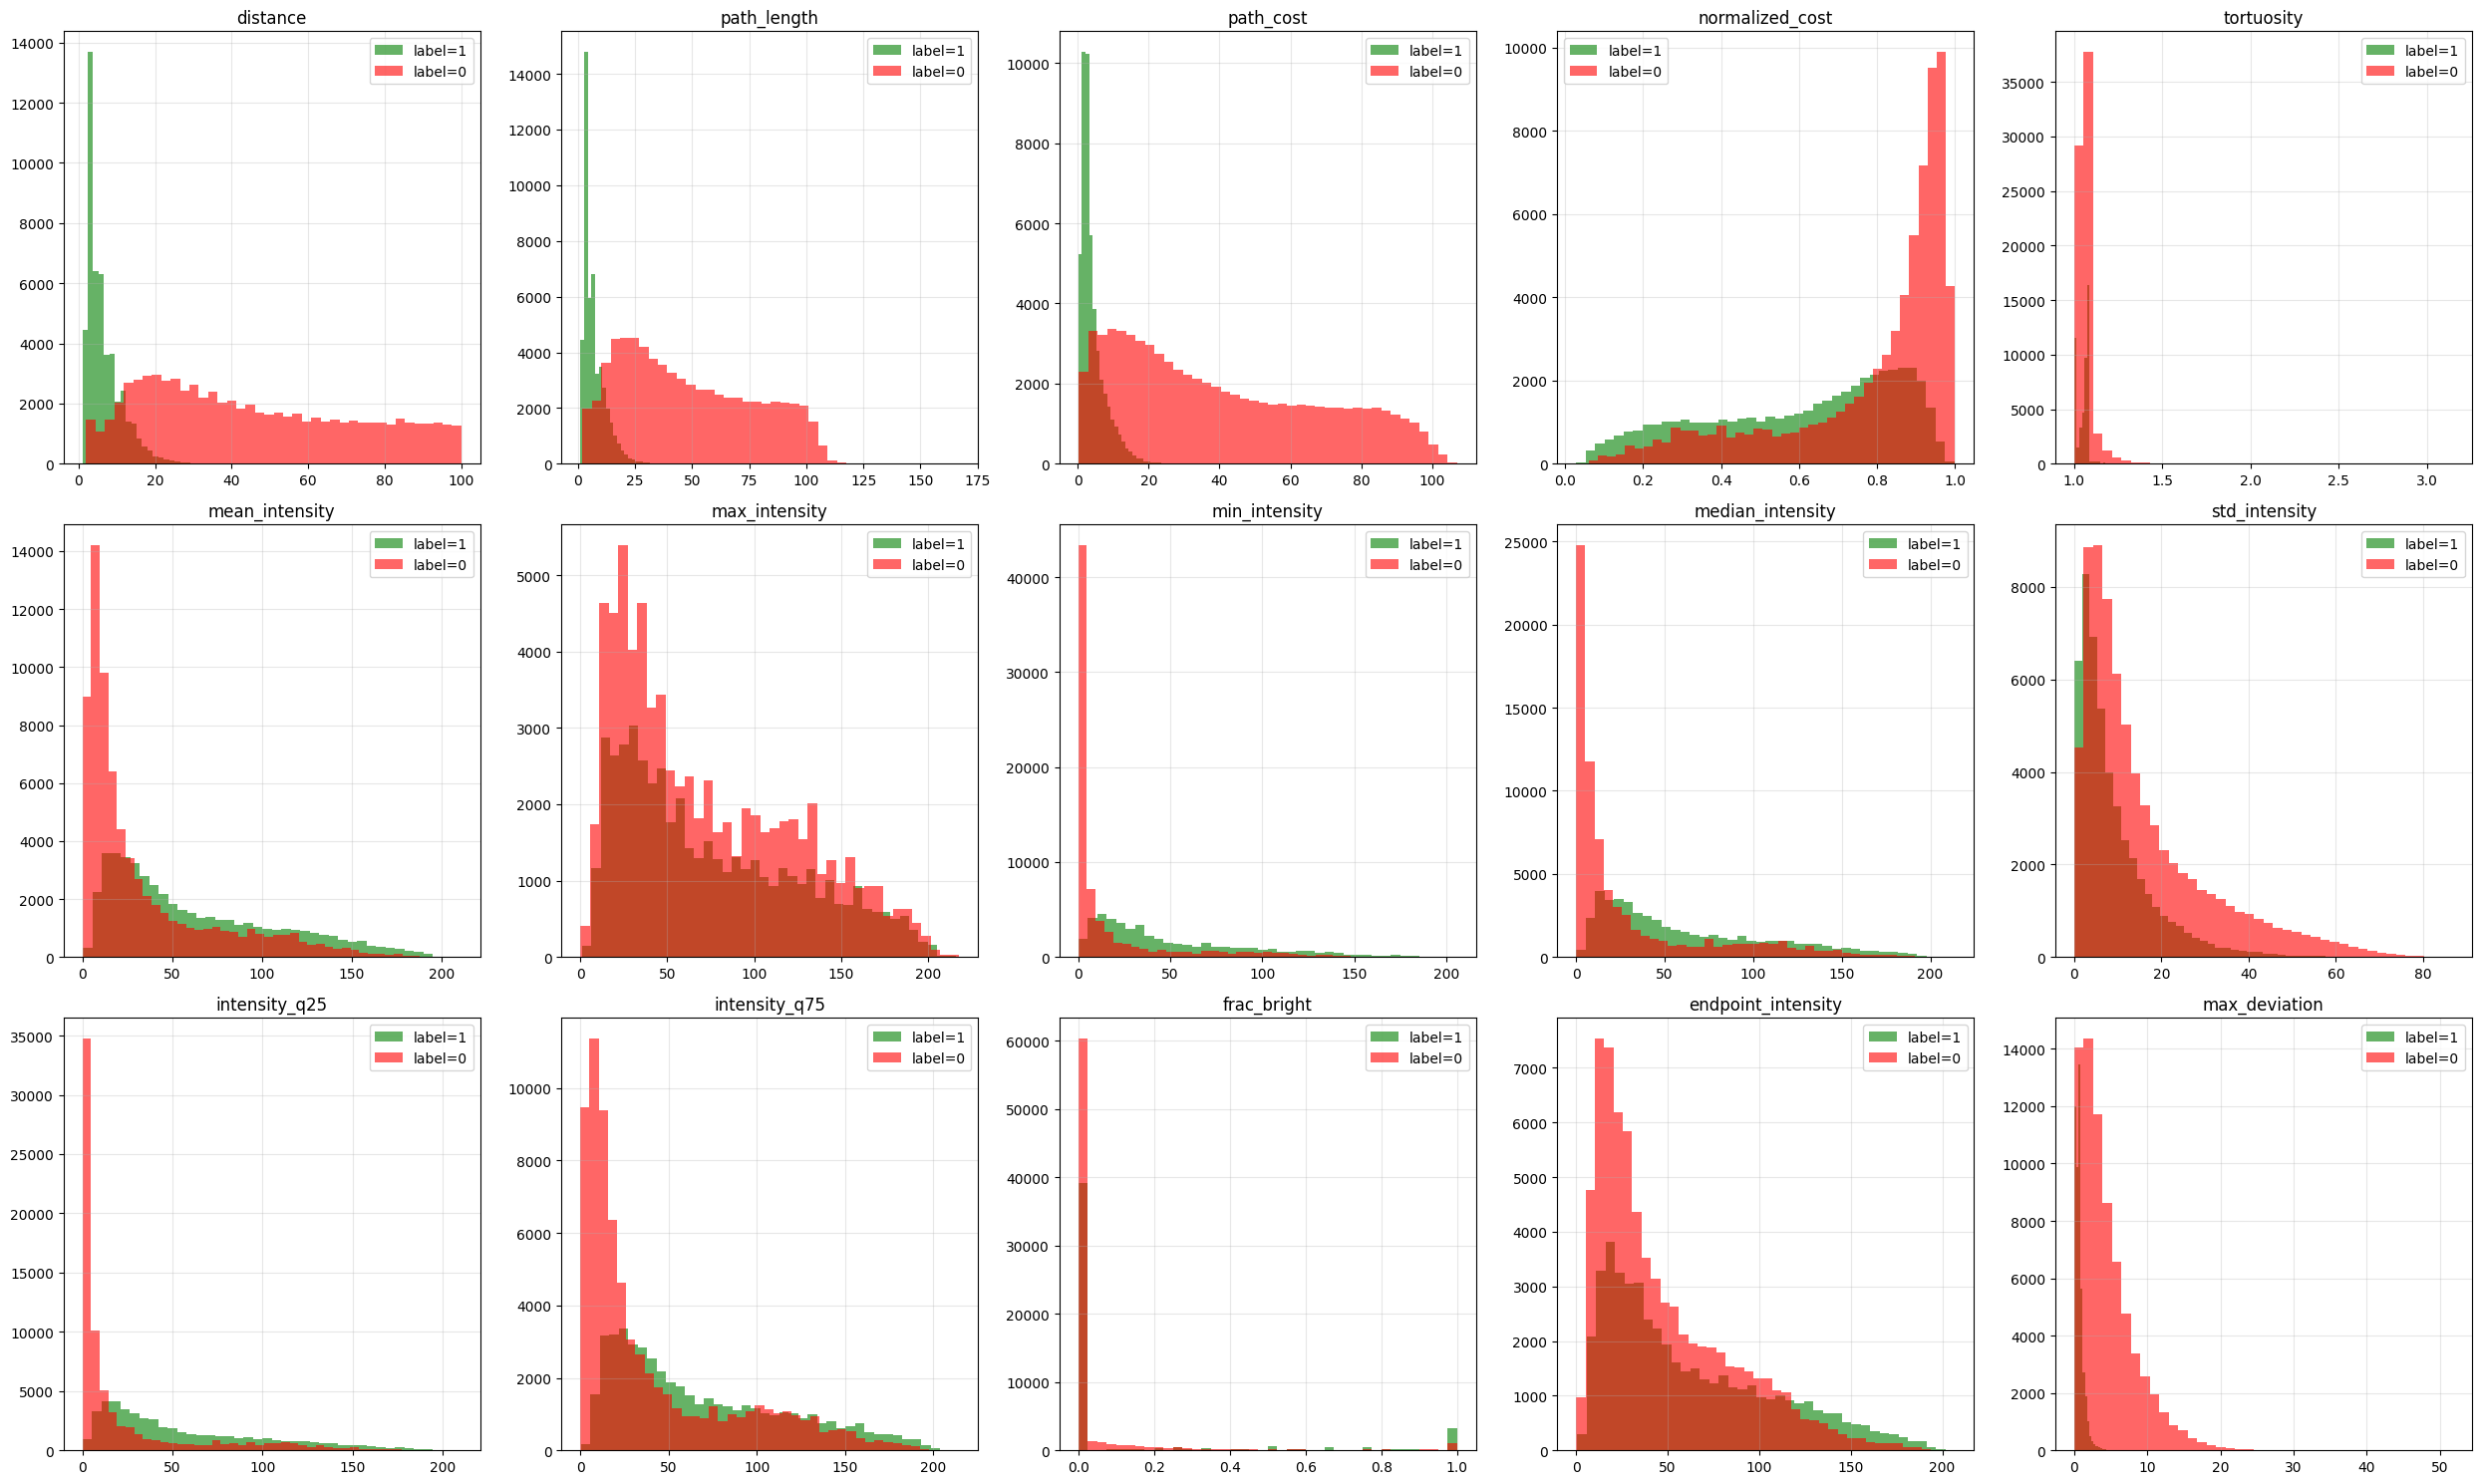

In [6]:
FEATURES = [
    'distance',"path_length","path_cost", 'normalized_cost', 'tortuosity',
    'mean_intensity', 'max_intensity', 'min_intensity', 'median_intensity',
    'std_intensity', 'intensity_q25', 'intensity_q75',
    'frac_bright', 'endpoint_intensity', 'max_deviation',
]

fig, axes = plt.subplots(3, 5, figsize=(25, 15))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    balanced_df[balanced_df['label'] == 1][feat].hist(bins=40, alpha=0.6, color='green', label='label=1', ax=ax)
    balanced_df[balanced_df['label'] == 0][feat].hist(bins=40, alpha=0.6, color='red',   label='label=0', ax=ax)
    ax.set_title(feat)
    ax.legend()
    ax.grid(True, alpha=0.3)

for j in range(len(FEATURES), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 5. Train / Test Split

In [7]:
X = balanced_df[FEATURES].values
y = balanced_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {len(X_train)}  (pos={y_train.sum()}, neg={(y_train==0).sum()})")
print(f"Test:  {len(X_test)}   (pos={y_test.sum()},  neg={(y_test==0).sum()})")

Train: 96324  (pos=38530, neg=57794)
Test:  24081   (pos=9632,  neg=14449)


## 6. XGBoost 訓練

In [8]:
model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)
print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-auc:0.96019
[50]	validation_0-auc:0.96353
[100]	validation_0-auc:0.96422
[150]	validation_0-auc:0.96458


/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/xgboost/callback.py:385: UserWarning: [11:21:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[200]	validation_0-auc:0.96488
[250]	validation_0-auc:0.96509
[299]	validation_0-auc:0.96515

Best iteration: 279


## 7. 評估

In [9]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['label=0 (bad)', 'label=1 (good)']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

                precision    recall  f1-score   support

 label=0 (bad)       0.94      0.90      0.92     14449
label=1 (good)       0.86      0.92      0.89      9632

      accuracy                           0.91     24081
     macro avg       0.90      0.91      0.91     24081
  weighted avg       0.91      0.91      0.91     24081

AUC-ROC: 0.9652


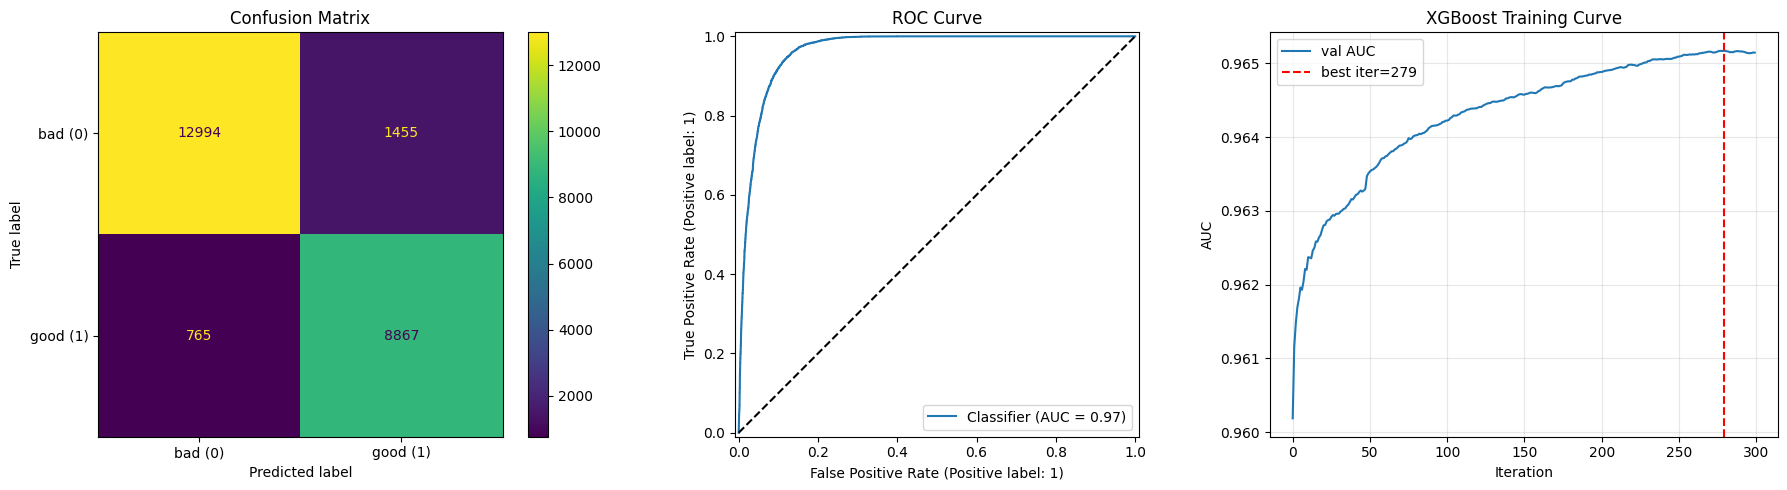

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['bad (0)', 'good (1)'], ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('ROC Curve')
axes[1].plot([0, 1], [0, 1], 'k--')

# Training AUC curve
results = model.evals_result()
epochs = len(results['validation_0']['auc'])
axes[2].plot(range(epochs), results['validation_0']['auc'], label='val AUC')
axes[2].axvline(model.best_iteration, color='r', linestyle='--', label=f'best iter={model.best_iteration}')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('AUC')
axes[2].set_title('XGBoost Training Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 特徵重要性

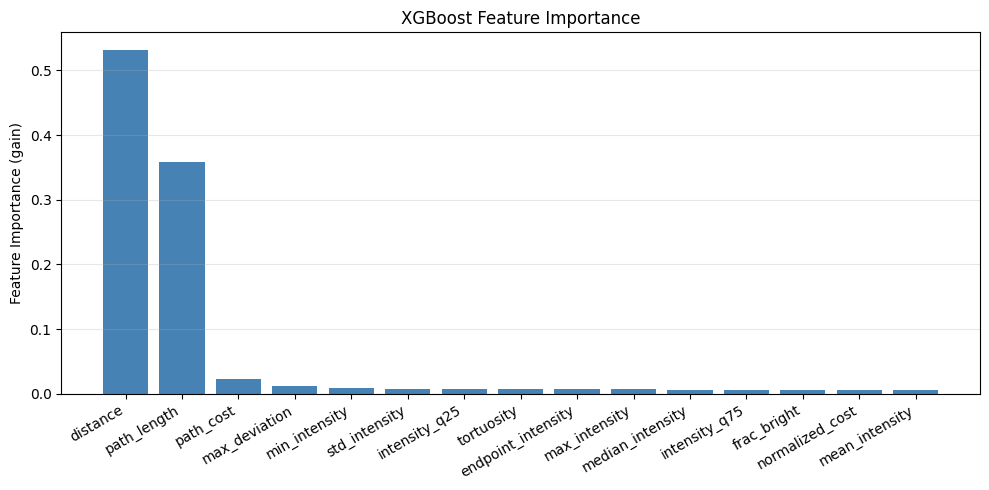

In [11]:
importances = model.feature_importances_
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(FEATURES)), importances[order], color='steelblue')
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels([FEATURES[i] for i in order], rotation=30, ha='right')
ax.set_ylabel('Feature Importance (gain)')
ax.set_title('XGBoost Feature Importance')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 9. Per-Sample Accuracy

In [12]:
model.save_model('xgb_connection_filter.json')

In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score

rows = []
for sid, df in zip(SAMPLE_IDS, all_dfs):
    X_s = scaler.transform(df[FEATURES].values)
    y_s = df['label'].values

    y_pred_s  = model.predict(X_s)
    y_proba_s = model.predict_proba(X_s)[:, 1]

    n_pos = int(y_s.sum())
    n_neg = int((y_s == 0).sum())
    acc   = accuracy_score(y_s, y_pred_s)
    auc   = roc_auc_score(y_s, y_proba_s) if n_pos > 0 and n_neg > 0 else float('nan')

    rows.append({
        'sample_id': sid,
        'n_total':   len(y_s),
        'n_pos':     n_pos,
        'n_neg':     n_neg,
        'accuracy':  round(acc, 4),
        'auc_roc':   round(auc, 4),
    })

per_sample_df = pd.DataFrame(rows)
per_sample_df = per_sample_df.sort_values('accuracy', ascending=True).reset_index(drop=True)

print(per_sample_df.to_string(index=False))
print(f"\nMean accuracy : {per_sample_df['accuracy'].mean():.4f}")
print(f"Mean AUC-ROC  : {per_sample_df['auc_roc'].mean():.4f}")

sample_id  n_total  n_pos  n_neg  accuracy  auc_roc
 S226-2_b    17005   1635  15370    0.8714   0.9551
 S558-2_a    38708   3463  35245    0.8776   0.9577
 S226-2_a    20835   2033  18802    0.8876   0.9575
 S222-2_a    44490   1941  42549    0.8954   0.9680
 S236-2_b    39889   3293  36596    0.9001   0.9628
S1585-2_a     2540    240   2300    0.9008   0.9615
 S558-2_b    13643    879  12764    0.9020   0.9659
 S222-2_b    48302   2632  45670    0.9022   0.9650
 S487-2_b    53898   5700  48198    0.9025   0.9704
 S341-2_b    50581   3942  46639    0.9025   0.9683
 S236-2_a    51822   4791  47031    0.9031   0.9705
 S341-2_a    60681   5132  55549    0.9132   0.9708
 S487-2_a    83469   8271  75198    0.9147   0.9749
S1616-2_a    32918   3600  29318    0.9219   0.9711
S1585-2_b     2888    383   2505    0.9328   0.9706
S1140-2_b     1059     98    961    0.9433   0.9764
S1140-2_a     1309    129   1180    0.9473   0.9777

Mean accuracy : 0.9070
Mean AUC-ROC  : 0.9673


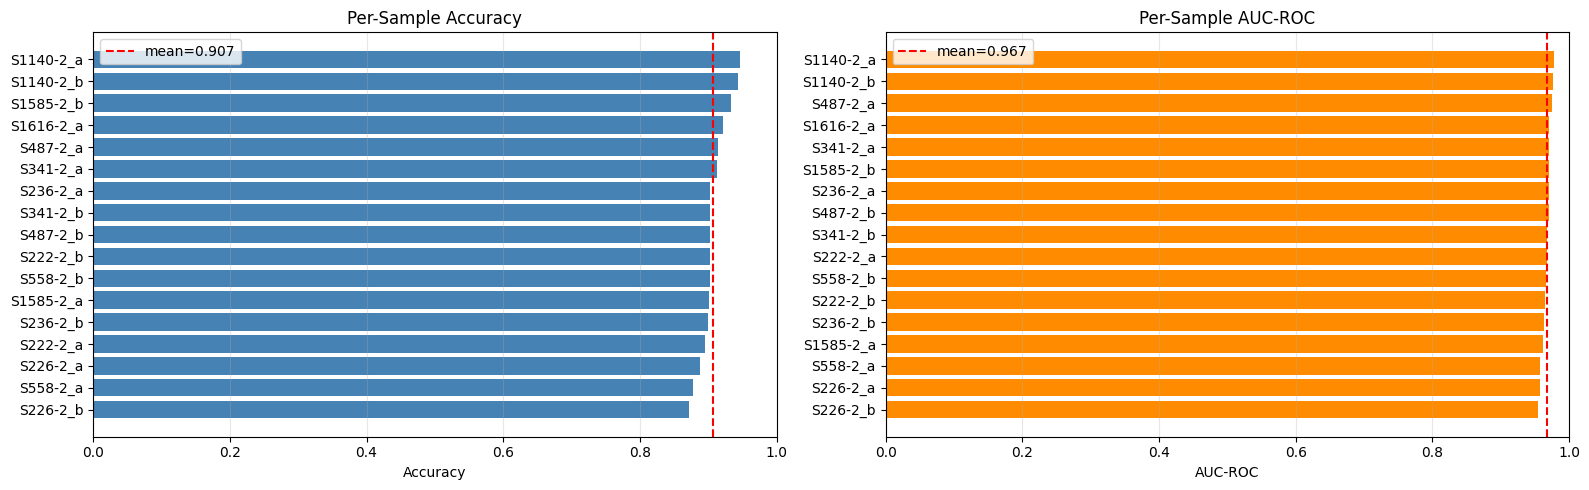

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sorted_df = per_sample_df.sort_values('accuracy')

axes[0].barh(sorted_df['sample_id'], sorted_df['accuracy'], color='steelblue')
axes[0].axvline(per_sample_df['accuracy'].mean(), color='red', linestyle='--',
                label=f"mean={per_sample_df['accuracy'].mean():.3f}")
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Per-Sample Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].set_xlim(0, 1)

sorted_auc = per_sample_df.sort_values('auc_roc')
axes[1].barh(sorted_auc['sample_id'], sorted_auc['auc_roc'], color='darkorange')
axes[1].axvline(per_sample_df['auc_roc'].mean(), color='red', linestyle='--',
                label=f"mean={per_sample_df['auc_roc'].mean():.3f}")
axes[1].set_xlabel('AUC-ROC')
axes[1].set_title('Per-Sample AUC-ROC')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 10. 單張樣本視覺化

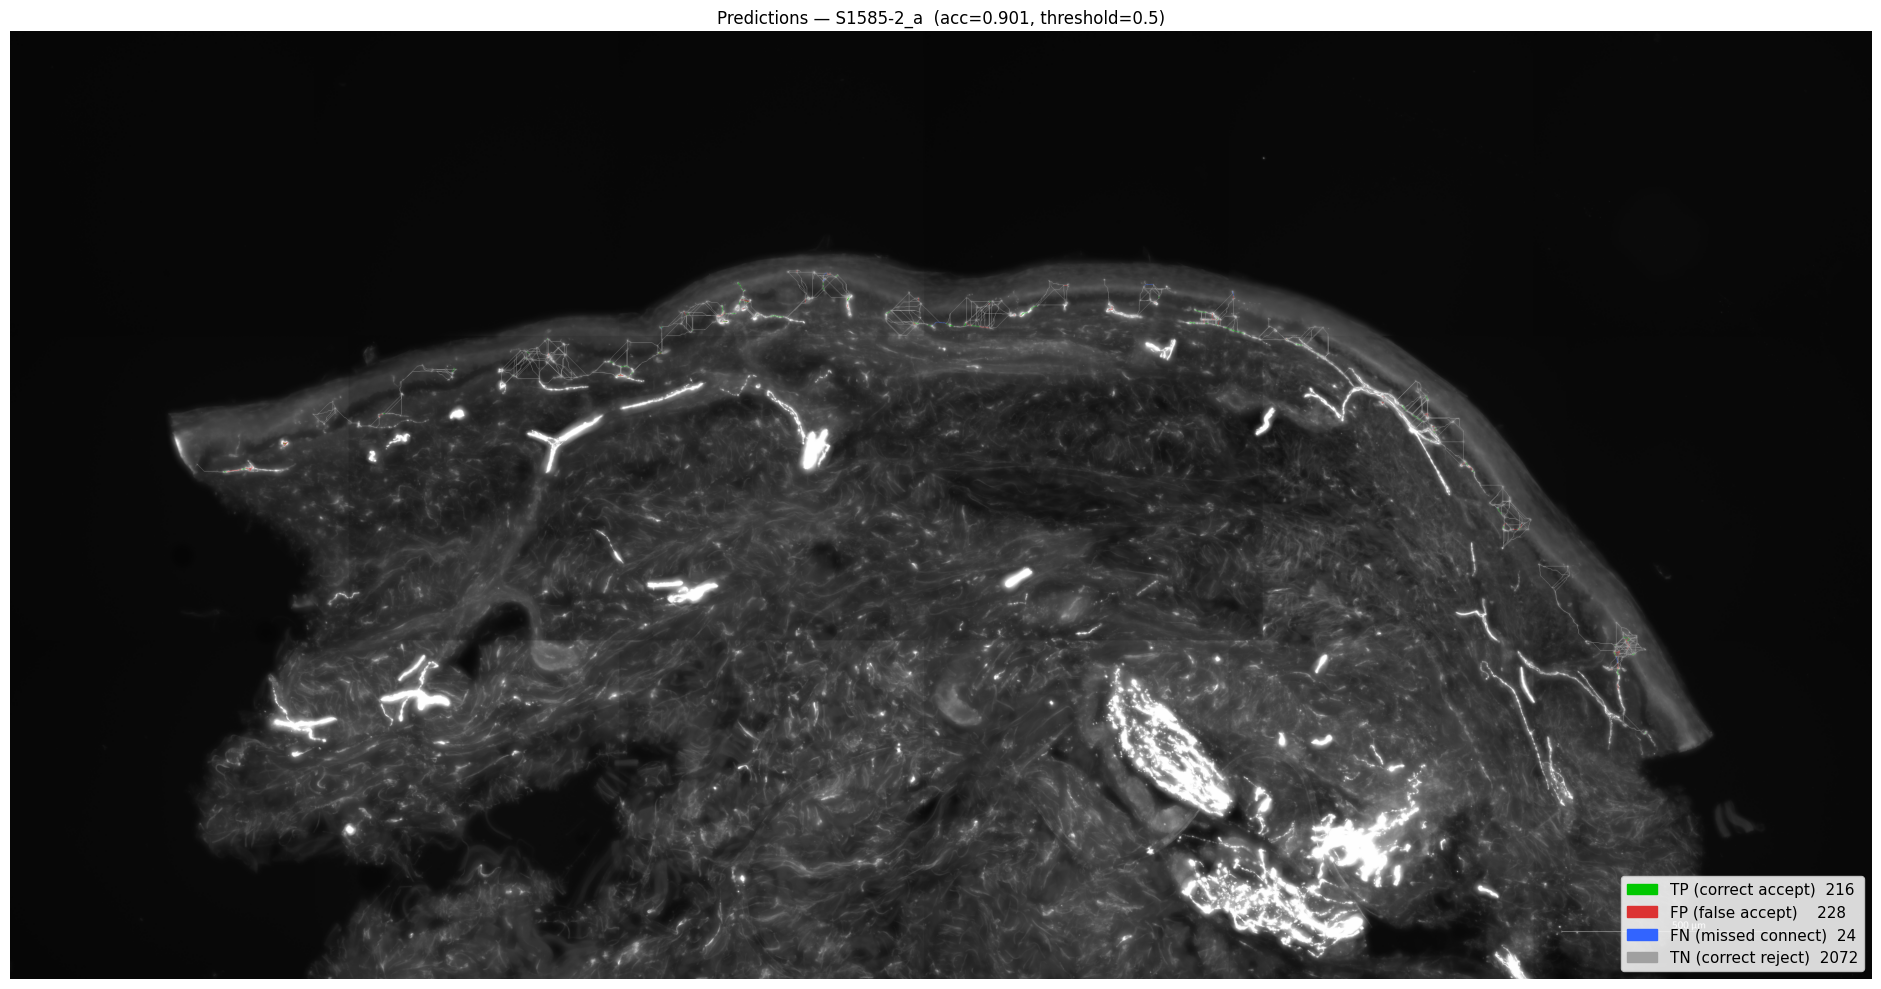

{'TP': 216, 'TN': 2072, 'FP': 228, 'FN': 24}


In [15]:

# ── Config ────────────────────────────────────────────────────────────────────
VIS_SAMPLE_ID  = "S1585-2_a"   # change to any sample id
PROB_THRESHOLD = 0.5             # decision boundary for coloring

vis_df = full_df[full_df['image_id'] == VIS_SAMPLE_ID].reset_index(drop=True)

pkl_path = DATASET_DIR / f'dataset_{VIS_SAMPLE_ID}_paths.pkl'
img_path = DATA_DIR / VIS_SAMPLE_ID / 'image.png'

orig_bgr  = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
orig_rgb  = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
orig_green = orig_rgb[:, :, 1]  # green channel for feature extraction

# ── Predict ───────────────────────────────────────────────────────────────────
X_vis  = scaler.transform(vis_df[FEATURES].values)
y_vis  = vis_df['label'].values
proba  = model.predict_proba(X_vis)[:, 1]
pred   = (proba >= PROB_THRESHOLD).astype(int)

# ── Draw paths ────────────────────────────────────────────────────────────────
# TP=green, TN=gray, FP=red, FN=blue
COLOR_TP = (0, 200, 0)
COLOR_TN = (160, 160, 160)
COLOR_FP = (220, 50, 50)
COLOR_FN = (50, 100, 255)

canvas = cv2.cvtColor(orig_green, cv2.COLOR_GRAY2RGB).copy()

id_col = 'pair_id' if 'pair_id' in vis_df.columns else 'sample_id'

counts = {'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0}
for row_id, gt, pr in zip(vis_df[id_col], y_vis, pred):
    path = vis_df.loc[vis_df[id_col] == row_id, 'path'].values[0]
    if path is None:
        continue

    if   gt == 1 and pr == 1:  color = COLOR_TP; counts['TP'] += 1
    elif gt == 0 and pr == 0:  color = COLOR_TN; counts['TN'] += 1
    elif gt == 0 and pr == 1:  color = COLOR_FP; counts['FP'] += 1
    else:                      color = COLOR_FN; counts['FN'] += 1

    pts = np.array(path)
    canvas[pts[:, 0], pts[:, 1]] = color

# ── Plot ──────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch

fig, ax = plt.subplots(1, 1, figsize=(22, 10))

ax.imshow(canvas)
legend_patches = [
    Patch(color=np.array(COLOR_TP)/255, label=f'TP (correct accept)  {counts["TP"]}'),
    Patch(color=np.array(COLOR_FP)/255, label=f'FP (false accept)    {counts["FP"]}'),
    Patch(color=np.array(COLOR_FN)/255, label=f'FN (missed connect)  {counts["FN"]}'),
    Patch(color=np.array(COLOR_TN)/255, label=f'TN (correct reject)  {counts["TN"]}'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=11, framealpha=0.85)
acc = (counts['TP'] + counts['TN']) / max(sum(counts.values()), 1)
ax.set_title(f'Predictions — {VIS_SAMPLE_ID}  (acc={acc:.3f}, threshold={PROB_THRESHOLD})')
ax.axis('off')

plt.tight_layout()
plt.show()
print(counts)


In [16]:
import joblib
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']